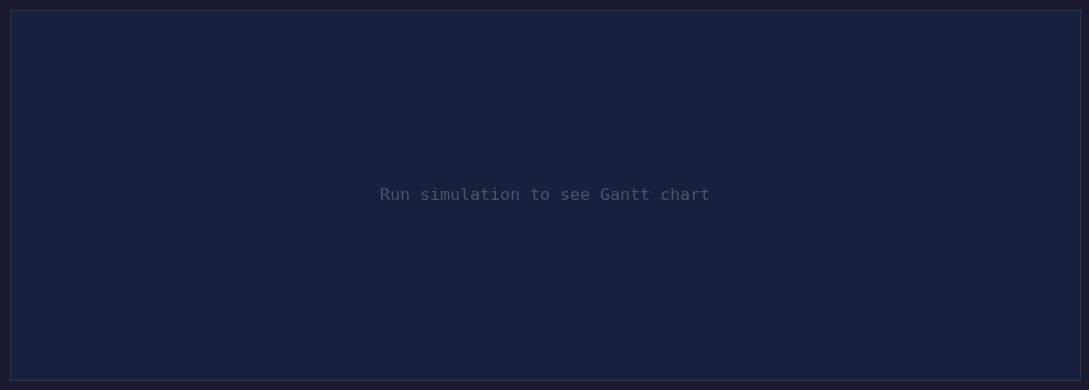

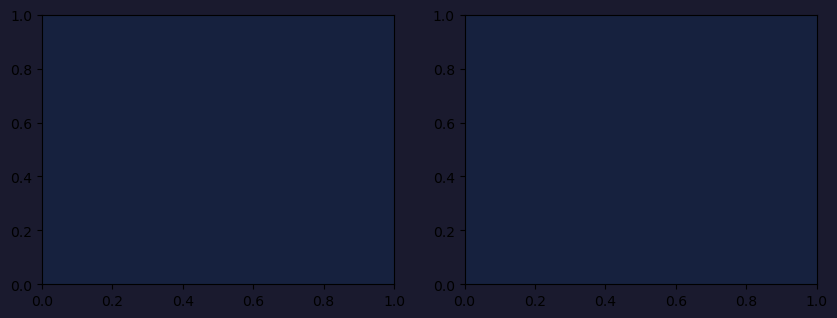

In [4]:

import tkinter as tk
from tkinter import ttk, messagebox
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import csv
import copy
import time
import threading

#  CLASS 1: Process

class Process:

    def __init__(self, pid, arrival_time, burst_time, priority=1):
        self.pid           = pid
        self.arrival_time  = arrival_time
        self.burst_time    = burst_time
        self.priority      = priority

        self.remaining     = burst_time
        self.finish_time   = 0
        self.waiting_time  = 0
        self.turnaround    = 0
        self.response_time = -1
        self.state         = "Ready"

    def reset(self):
        self.remaining     = self.burst_time
        self.finish_time   = 0
        self.waiting_time  = 0
        self.turnaround    = 0
        self.response_time = -1
        self.state         = "Ready"

    def __repr__(self):
        return (f"P{self.pid}(AT={self.arrival_time}, "
                f"BT={self.burst_time}, PR={self.priority})")

class Scheduler:
    def __init__(self, processes):
        self.processes = [copy.deepcopy(p) for p in processes]

    def _reset_all(self):
        for p in self.processes:
            p.reset()

    def _calc_metrics(self, gantt):
        procs = self.processes
        n = len(procs)
        total_time  = gantt[-1]["end"] if gantt else 0
        busy_time   = sum(b["end"] - b["start"]
                          for b in gantt if b["pid"] != "IDLE")
        avg_wt      = sum(p.waiting_time  for p in procs) / n
        avg_tat     = sum(p.turnaround    for p in procs) / n
        avg_rt      = sum(p.response_time for p in procs) / n
        cpu_util    = (busy_time / total_time * 100) if total_time else 0
        throughput  = n / total_time if total_time else 0
        ctx_switches = sum(
            1 for i in range(1, len(gantt))
            if gantt[i]["pid"] != "IDLE"
            and gantt[i-1]["pid"] != "IDLE"
            and gantt[i]["pid"] != gantt[i-1]["pid"]
        )
        return {
            "avg_wt":        round(avg_wt,       2),
            "avg_tat":       round(avg_tat,      2),
            "avg_rt":        round(avg_rt,       2),
            "cpu_util":      round(cpu_util,     2),
            "throughput":    round(throughput,   4),
            "ctx_switches":  ctx_switches,
            "total_time":    total_time,
        }

    #  ALGORITHM 1: FCFS
    
    def fcfs(self):
    
        self._reset_all()
        procs = sorted(self.processes, key=lambda p: (p.arrival_time, p.pid))
        gantt = []
        t = 0
        for p in procs:
            if t < p.arrival_time:
                gantt.append({"pid": "IDLE", "start": t, "end": p.arrival_time})
                t = p.arrival_time
            p.response_time = t - p.arrival_time
            p.waiting_time  = t - p.arrival_time
            gantt.append({"pid": p.pid, "start": t, "end": t + p.burst_time})
            t += p.burst_time
            p.finish_time   = t
            p.turnaround    = p.finish_time - p.arrival_time
            p.state         = "Completed"
        metrics = self._calc_metrics(gantt)
        return gantt, self.processes, metrics

    #  ALGORITHM 2: SJF Non-Preemptive

    def sjf(self):
        self._reset_all()
        procs  = self.processes[:]
        gantt  = []
        t      = 0
        done   = 0
        n      = len(procs)
        while done < n:
            ready = [p for p in procs if p.arrival_time <= t and p.finish_time == 0]
            if not ready:
                next_arrival = min(p.arrival_time for p in procs if p.finish_time == 0)
                gantt.append({"pid": "IDLE", "start": t, "end": next_arrival})
                t = next_arrival
                continue
            p = min(ready, key=lambda x: (x.burst_time, x.arrival_time))
            if p.response_time == -1:
                p.response_time = t - p.arrival_time
            p.waiting_time = t - p.arrival_time
            gantt.append({"pid": p.pid, "start": t, "end": t + p.burst_time})
            t            += p.burst_time
            p.finish_time = t
            p.turnaround  = p.finish_time - p.arrival_time
            p.state       = "Completed"
            done         += 1
        metrics = self._calc_metrics(gantt)
        return gantt, self.processes, metrics

    #  ALGORITHM 3: SRTF (Preemptive SJF)
    # ──────────────────────────────────────────
    def srtf(self):
        self._reset_all()
        procs  = self.processes[:]
        n      = len(procs)
        gantt  = []
        t      = 0
        done   = 0
        current_pid = None
        seg_start   = 0

        while done < n:
            ready = [p for p in procs if p.arrival_time <= t and p.remaining > 0]
            if not ready:
                if current_pid is not None:
                    gantt.append({"pid": current_pid, "start": seg_start, "end": t})
                    current_pid = None
                next_arrival = min(p.arrival_time for p in procs  if p.remaining > 0)
                idle_start = t
                t = next_arrival
                gantt.append({"pid": "IDLE", "start": idle_start, "end": t})
                seg_start = t
                continue
            p = min(ready, key=lambda x: (x.remaining, x.arrival_time, x.pid))
            if p.response_time == -1:
                p.response_time = t - p.arrival_time

            if p.pid != current_pid:
                if current_pid is not None:
                    gantt.append({"pid": current_pid, "start": seg_start, "end": t})
                current_pid = p.pid
                seg_start   = t
            p.remaining -= 1
            t += 1
            if p.remaining == 0:
                p.finish_time  = t
                p.turnaround   = p.finish_time - p.arrival_time
                p.waiting_time = p.turnaround - p.burst_time
                p.state        = "Completed"
                done          += 1
                gantt.append({"pid": current_pid,"start": seg_start, "end": t})
                current_pid = None
                seg_start   = t
        merged = []
        for block in gantt:
            if (merged and merged[-1]["pid"] == block["pid"] and merged[-1]["end"] == block["start"]):
                merged[-1]["end"] = block["end"]
            else:
                merged.append(dict(block))
        metrics = self._calc_metrics(merged)
        return merged, self.processes, metrics

    #  ALGORITHM 4: Round Robin
    # ──────────────────────────────────────────
    def round_robin(self, quantum=2):
        self._reset_all()
        procs   = sorted(self.processes, key=lambda p: p.arrival_time)
        gantt   = []
        t       = 0
        queue   = []
        idx     = 0
        done    = 0
        n       = len(procs)
        arrived = set()
        while idx < n and procs[idx].arrival_time <= t:
            queue.append(procs[idx])
            arrived.add(procs[idx].pid)
            idx += 1
        while done < n:
            if not queue:
                t += 1
                while idx < n and procs[idx].arrival_time <= t:
                    if procs[idx].pid not in arrived:
                        queue.append(procs[idx])
                        arrived.add(procs[idx].pid)
                    idx += 1
                continue
            p = queue.pop(0)
            exec_t = min(p.remaining, quantum)

            if p.response_time == -1:
                p.response_time = t - p.arrival_time

            gantt.append({"pid": p.pid, "start": t, "end": t + exec_t})
            t += exec_t
            p.remaining -= exec_t
            while idx < n and procs[idx].arrival_time <= t:
                if procs[idx].pid not in arrived:
                    queue.append(procs[idx])
                    arrived.add(procs[idx].pid)
                idx += 1

            if p.remaining > 0:
                queue.append(p)
            else:
                p.finish_time  = t
                p.turnaround   = p.finish_time - p.arrival_time
                p.waiting_time = p.turnaround - p.burst_time
                p.state        = "Completed"
                done += 1

        metrics = self._calc_metrics(gantt)
        return gantt, self.processes, metrics

    #  ALGORITHM 5: Priority (Non-Preemptive)
    # ──────────────────────────────────────────
    def priority_scheduling(self):
        self._reset_all()
        procs  = self.processes[:]
        gantt  = []
        t      = 0
        done   = 0
        n      = len(procs)
        while done < n:
            ready = [p for p in procs if p.arrival_time <= t and p.finish_time == 0]
            if not ready:
                next_arrival = min(p.arrival_time for p in procs if p.finish_time == 0)
                gantt.append({"pid": "IDLE", "start": t, "end": next_arrival})
                t = next_arrival
                continue
            p = min(ready, key=lambda x: (x.priority, x.arrival_time))
            if p.response_time == -1:
                p.response_time = t - p.arrival_time
            p.waiting_time = t - p.arrival_time
            gantt.append({"pid": p.pid, "start": t, "end": t + p.burst_time})
            t            += p.burst_time
            p.finish_time = t
            p.turnaround  = p.finish_time - p.arrival_time
            p.state       = "Completed"
            done         += 1
        metrics = self._calc_metrics(gantt)
        return gantt, self.processes, metrics

    #  ALGORITHM 6: Priority (Preemptive)
    # ──────────────────────────────────────────
    def priority_preemptive(self):

        self._reset_all()
        procs       = self.processes[:]
        n           = len(procs)
        gantt       = []
        t           = 0
        done        = 0
        current_pid = None
        seg_start   = 0

        while done < n:
            ready = [p for p in procs if p.arrival_time <= t and p.remaining > 0]

            if not ready:
                if current_pid is not None:
                    gantt.append({"pid": current_pid,
                                  "start": seg_start, "end": t})
                    current_pid = None
                next_arrival = min(p.arrival_time for p in procs if p.remaining > 0)
                gantt.append({"pid": "IDLE", "start": t, "end": next_arrival})
                t         = next_arrival
                seg_start = t
                continue
            p = min(ready, key=lambda x: (x.priority, x.arrival_time, x.pid))

            if p.response_time == -1:
                p.response_time = t - p.arrival_time

            # Preemption check
            if p.pid != current_pid:
                if current_pid is not None:
                    gantt.append({"pid": current_pid,
                                  "start": seg_start, "end": t})
                current_pid = p.pid
                seg_start   = t
            p.remaining -= 1
            t           += 1

            if p.remaining == 0:
                p.finish_time  = t
                p.turnaround   = p.finish_time - p.arrival_time
                p.waiting_time = p.turnaround - p.burst_time
                p.state        = "Completed"
                done          += 1
                gantt.append({"pid": current_pid,
                              "start": seg_start, "end": t})
                current_pid = None
                seg_start   = t

        merged = []
        for block in gantt:
            if (merged and merged[-1]["pid"] == block["pid"]
                    and merged[-1]["end"] == block["start"]):
                merged[-1]["end"] = block["end"]
            else:
                merged.append(dict(block))
        metrics = self._calc_metrics(merged)
        return merged, self.processes, metrics

#  CLASS 3: SimulatorApp  (Tkinter UI)
# ──────────────────────────────────────────────
class SimulatorApp:

    COLORS = [
        "#4e79a7","#f28e2b","#e15759","#76b7b2",
        "#59a14f","#edc948","#b07aa1","#ff9da7",
        "#9c755f","#bab0ac"
    ]

    def __init__(self, root):
        self.root    = root
        self.root.title("CPU Process Scheduling ")
        self.root.configure(bg="#1a1a2e")
        self.root.geometry("1100x750")
        self.root.minsize(900, 620)

        self.processes    = []
        self.pid_counter  = 1
        self.gantt_data   = []
        self.result_procs = []
        self.metrics      = {}
        self.sim_running  = False
        self.quantum_var  = tk.IntVar(value=2)
        self.algo_var     = tk.StringVar(value="FCFS")
        self.speed_var    = tk.IntVar(value=500)

        self._build_ui()
        self._add_default_processes()

    # ══════════════════════════════════════════
    #  UI CONSTRUCTION
    # ══════════════════════════════════════════
    def _build_ui(self):
        self._style()
        self._header()
        self._notebook()

    def _style(self):
        style = ttk.Style()
        style.theme_use("clam")
        style.configure("TNotebook",
                        background="#1a1a2e", borderwidth=0)
        style.configure("TNotebook.Tab",
                        background="#16213e", foreground="#a0aec0",
                        padding=[14, 6], font=("Consolas", 10, "bold"))
        style.map("TNotebook.Tab",
                  background=[("selected", "#0f3460")],
                  foreground=[("selected", "#4fc3f7")])
        style.configure("Treeview",
                        background="#16213e", foreground="#e2e8f0",
                        fieldbackground="#16213e", rowheight=26,
                        font=("Consolas", 9))
        style.configure("Treeview.Heading",
                        background="#0f3460", foreground="#4fc3f7",
                        font=("Consolas", 9, "bold"), relief="flat")
        style.map("Treeview", background=[("selected","#1d4ed8")])
        style.configure("Accent.TButton",
                        background="#1d4ed8", foreground="white",
                        font=("Consolas", 9, "bold"), padding=[8,4])
        style.configure("Danger.TButton",
                        background="#dc2626", foreground="white",
                        font=("Consolas", 9, "bold"), padding=[8,4])

    def _header(self):
        hdr = tk.Frame(self.root, bg="#0f3460", height=52)
        hdr.pack(fill="x")
        hdr.pack_propagate(False)

        tk.Label(hdr, text=" CPU PROCESS SCHEDULING ",
                 bg="#0f3460", fg="#4fc3f7",
                 font=("Consolas", 14, "bold")).pack(side="left", padx=20, pady=12)

        tk.Label(hdr, text="  ",
                 bg="#0f3460", fg="#718096",
                 font=("Consolas", 9)).pack(side="left", padx=4)

    def _notebook(self):
        nb = ttk.Notebook(self.root)
        nb.pack(fill="both", expand=True, padx=8, pady=(4,8))

        self.tab_sim   = tk.Frame(nb, bg="#1a1a2e")
        self.tab_gantt = tk.Frame(nb, bg="#1a1a2e")
        self.tab_cmp   = tk.Frame(nb, bg="#1a1a2e")

        nb.add(self.tab_sim,   text=" 🖥  Simulation ")
        nb.add(self.tab_gantt, text=" 📊  Gantt Chart ")
        nb.add(self.tab_cmp,   text=" ⚡  Compare All ")

        self._build_simulation_tab()
        self._build_gantt_tab()
        self._build_compare_tab()

    # ──────────────────────────────────────────
    #  TAB 1: SIMULATION
    # ──────────────────────────────────────────
    def _build_simulation_tab(self):
        tab = self.tab_sim

        # ── LEFT PANEL ──
        left = tk.Frame(tab, bg="#16213e", width=320)
        left.pack(side="left", fill="y", padx=(8,4), pady=8)
        left.pack_propagate(False)

        # Algorithm selection
        self._section(left, "ALGORITHM")

        # Group: SJF with sub-options
        algos_simple = ["FCFS", "Round Robin", "Priority"]
        sjf_options  = [
            ("SJF — Non-Preemptive", "SJF"),
            ("SRTF — Preemptive SJF", "SRTF"),
        ]

        tk.Radiobutton(left, text="FCFS", variable=self.algo_var,
                       value="FCFS", bg="#16213e", fg="#e2e8f0",
                       selectcolor="#0f3460", activebackground="#16213e",
                       activeforeground="#4fc3f7",
                       font=("Consolas",10), command=self._algo_changed
                       ).pack(anchor="w", padx=16, pady=2)

        # SJF sub-group with visual indent
        sjf_group = tk.Frame(left, bg="#16213e")
        sjf_group.pack(fill="x", padx=6, pady=0)

        tk.Label(sjf_group, text="  SJF:", bg="#16213e", fg="#718096",
                 font=("Consolas", 9, "bold")).pack(anchor="w", padx=10, pady=(6,0))

        for label, value in sjf_options:
            tk.Radiobutton(sjf_group, text=label, variable=self.algo_var,
                           value=value, bg="#16213e", fg="#e2e8f0",
                           selectcolor="#0f3460", activebackground="#16213e",
                           activeforeground="#4fc3f7",
                           font=("Consolas",10), command=self._algo_changed
                           ).pack(anchor="w", padx=26, pady=1)

        tk.Radiobutton(left, text="Round Robin", variable=self.algo_var,
                       value="Round Robin", bg="#16213e", fg="#e2e8f0",
                       selectcolor="#0f3460", activebackground="#16213e",
                       activeforeground="#4fc3f7",
                       font=("Consolas",10), command=self._algo_changed
                       ).pack(anchor="w", padx=16, pady=2)

        # Priority sub-group with visual indent
        pri_group = tk.Frame(left, bg="#16213e")
        pri_group.pack(fill="x", padx=6, pady=0)

        tk.Label(pri_group, text="  Priority:", bg="#16213e", fg="#718096",
                 font=("Consolas", 9, "bold")).pack(anchor="w", padx=10, pady=(6,0))

        for label, value in [("Priority — Non-Preemptive", "Priority"),
                              ("Priority — Preemptive",     "Priority-P")]:
            tk.Radiobutton(pri_group, text=label, variable=self.algo_var,
                           value=value, bg="#16213e", fg="#e2e8f0",
                           selectcolor="#0f3460", activebackground="#16213e",
                           activeforeground="#4fc3f7",
                           font=("Consolas",10), command=self._algo_changed
                           ).pack(anchor="w", padx=26, pady=1)

        # Quantum (RR only)
        self.rr_frame = tk.Frame(left, bg="#16213e")
        self.rr_frame.pack(fill="x", padx=12, pady=(4,0))
        tk.Label(self.rr_frame, text="Time Quantum:", bg="#16213e",
                 fg="#718096", font=("Consolas",9)).pack(side="left")
        tk.Spinbox(self.rr_frame, from_=1, to=20, textvariable=self.quantum_var,
                   width=4, bg="#0f3460", fg="#4fc3f7",
                   font=("Consolas",10), buttonbackground="#0f3460"
                   ).pack(side="left", padx=6)
        self.rr_frame.pack_forget()

        # Speed
        self._section(left, "SIM SPEED")
        spd_row = tk.Frame(left, bg="#16213e")
        spd_row.pack(fill="x", padx=12)
        tk.Label(spd_row, text="Fast", bg="#16213e", fg="#718096",
                 font=("Consolas",8)).pack(side="left")
        tk.Scale(spd_row, from_=100, to=1500, orient="horizontal",
                 variable=self.speed_var, bg="#16213e", fg="#4fc3f7",
                 troughcolor="#0f3460", highlightthickness=0,
                 showvalue=False, length=160
                 ).pack(side="left", padx=4)
        tk.Label(spd_row, text="Slow", bg="#16213e", fg="#718096",
                 font=("Consolas",8)).pack(side="left")

        # Controls
        self._section(left, "CONTROLS")
        for txt, cmd, style_ in [
            ("▶  Run Simulation",  self._run,   "#1d4ed8"),
            ("⏭  Step by Step",    self._step,  "#0f3460"),
            ("↺  Reset",           self._reset, "#374151"),
            ("⬇  Export CSV",      self._export,"#065f46"),
        ]:
            tk.Button(left, text=txt, command=cmd,
                      bg=style_, fg="white",
                      font=("Consolas",9,"bold"),
                      relief="flat", padx=10, pady=5,
                      cursor="hand2", activebackground="#1e40af",
                      activeforeground="white"
                      ).pack(fill="x", padx=12, pady=3)

        # Process states legend
        self._section(left, "PROCESS STATES")
        for state, color in [("Running","#3b82f6"),("Ready","#f59e0b"),
                              ("Waiting","#6b7280"),("Completed","#10b981")]:
            row = tk.Frame(left, bg="#16213e")
            row.pack(anchor="w", padx=16, pady=2)
            c = tk.Canvas(row, width=12, height=12, bg="#16213e",
                          highlightthickness=0)
            c.pack(side="left")
            c.create_oval(0,0,12,12, fill=color, outline="")
            tk.Label(row, text=state, bg="#16213e", fg="#a0aec0",
                     font=("Consolas",9)).pack(side="left", padx=4)

        # ── RIGHT PANEL ──
        right = tk.Frame(tab, bg="#1a1a2e")
        right.pack(side="left", fill="both", expand=True, padx=(4,8), pady=8)

        # Process input table
        self._section(right, "PROCESS TABLE")
        tbl_frame = tk.Frame(right, bg="#1a1a2e")
        tbl_frame.pack(fill="x", padx=4)

        cols = ("PID","Arrival Time","Burst Time","Priority","State")
        self.tree = ttk.Treeview(tbl_frame, columns=cols, show="headings",
                                 height=6, selectmode="browse")
        for col in cols:
            self.tree.heading(col, text=col)
            self.tree.column(col, width=110, anchor="center")
        self.tree.pack(fill="x")

        btn_row = tk.Frame(right, bg="#1a1a2e")
        btn_row.pack(fill="x", padx=4, pady=6)
        for txt, cmd, bg in [
            ("+ Add Process",   self._add_proc_dialog, "#1d4ed8"),
            ("✎ Edit Selected", self._edit_proc,       "#374151"),
            ("✕ Remove",        self._remove_proc,     "#dc2626"),
            ("Clear All",       self._clear_procs,     "#374151"),
        ]:
            tk.Button(btn_row, text=txt, command=cmd,
                      bg=bg, fg="white", font=("Consolas",9,"bold"),
                      relief="flat", padx=8, pady=4, cursor="hand2"
                      ).pack(side="left", padx=4)

        # Status bar
        self._section(right, "STATUS")
        self.status_frame = tk.Frame(right, bg="#0f3460",
                                     relief="solid", bd=1)
        self.status_frame.pack(fill="x", padx=4, pady=4)

        self.lbl_cpu    = self._status_item(self.status_frame, "CPU", "IDLE", "#6b7280")
        self.lbl_clock  = self._status_item(self.status_frame, "Clock", "T=0", "#e2e8f0")
        self.lbl_rq     = self._status_item(self.status_frame, "Ready Queue", "0", "#f59e0b")
        self.lbl_done   = self._status_item(self.status_frame, "Completed", "0/0", "#10b981")
        self.lbl_ctx    = self._status_item(self.status_frame, "Ctx Switches", "0", "#e2e8f0")

        # Metrics
        self._section(right, "METRICS")
        metrics_frame = tk.Frame(right, bg="#1a1a2e")
        metrics_frame.pack(fill="x", padx=4)

        self.metric_labels = {}
        items = [
            ("Avg Wait Time",       "avg_wt",      "#3b82f6"),
            ("Avg Turnaround",      "avg_tat",      "#06b6d4"),
            ("Avg Response Time",   "avg_rt",       "#a78bfa"),
            ("CPU Utilization %",   "cpu_util",     "#10b981"),
            ("Throughput",          "throughput",   "#f59e0b"),
            ("Context Switches",    "ctx_switches", "#ef4444"),
        ]
        for i, (label, key, color) in enumerate(items):
            r, c = divmod(i, 3)
            card = tk.Frame(metrics_frame, bg="#16213e",
                            relief="solid", bd=1)
            card.grid(row=r, column=c, padx=4, pady=4,
                      sticky="ew", ipadx=8, ipady=6)
            metrics_frame.columnconfigure(c, weight=1)
            tk.Label(card, text=label, bg="#16213e", fg="#718096",
                     font=("Consolas",8,"bold")).pack()
            lbl = tk.Label(card, text="—", bg="#16213e", fg=color,
                           font=("Consolas",14,"bold"))
            lbl.pack()
            self.metric_labels[key] = lbl

        # Results table
        self._section(right, "RESULTS PER PROCESS")
        rcols = ("PID","AT","BT","Finish","Wait","Turnaround","Response","State")
        self.res_tree = ttk.Treeview(right, columns=rcols,
                                      show="headings", height=5)
        for col in rcols:
            self.res_tree.heading(col, text=col)
            self.res_tree.column(col, width=80, anchor="center")
        self.res_tree.pack(fill="x", padx=4, pady=4)

    # ──────────────────────────────────────────
    #  TAB 2: GANTT CHART
    # ──────────────────────────────────────────
    def _build_gantt_tab(self):
        tab = self.tab_gantt
        self.fig_gantt, self.ax_gantt = plt.subplots(figsize=(11,4),
                                                      facecolor="#1a1a2e")
        self.ax_gantt.set_facecolor("#16213e")
        self.gantt_canvas = FigureCanvasTkAgg(self.fig_gantt, master=tab)
        self.gantt_canvas.get_tk_widget().pack(fill="both", expand=True,
                                               padx=8, pady=8)
        self._draw_empty_gantt()

    # ──────────────────────────────────────────
    #  TAB 3: COMPARE ALL
    # ──────────────────────────────────────────
    def _build_compare_tab(self):
        tab = self.tab_cmp

        tk.Button(tab, text="⚡  Run All 6 Algorithms & Compare",
                  command=self._compare_all,
                  bg="#1d4ed8", fg="white",
                  font=("Consolas",11,"bold"),
                  relief="flat", padx=20, pady=8, cursor="hand2"
                  ).pack(pady=12)

        self._section(tab, "COMPARISON TABLE  (green = best · red = worst)")
        ccols = ("Algorithm","Avg Wait","Avg TAT","Avg Resp",
                 "CPU Util%","Throughput","Ctx Sw")
        self.cmp_tree = ttk.Treeview(tab, columns=ccols,
                                      show="headings", height=7)
        for col in ccols:
            self.cmp_tree.heading(col, text=col)
            self.cmp_tree.column(col, width=110, anchor="center")
        self.cmp_tree.pack(fill="x", padx=8, pady=4)
        self.cmp_tree.tag_configure("best",  background="#064e3b",
                                    foreground="#34d399")
        self.cmp_tree.tag_configure("worst", background="#450a0a",
                                    foreground="#ef4444")

        self._section(tab, "VISUAL COMPARISON — Average Wait & Turnaround Time")
        self.fig_cmp, (self.ax_wt, self.ax_tat) = plt.subplots(
            1, 2, figsize=(10, 3.5), facecolor="#1a1a2e")
        for ax in [self.ax_wt, self.ax_tat]:
            ax.set_facecolor("#16213e")
        self.cmp_canvas = FigureCanvasTkAgg(self.fig_cmp, master=tab)
        self.cmp_canvas.get_tk_widget().pack(fill="both", expand=True,
                                              padx=8, pady=4)

    # ══════════════════════════════════════════
    #  HELPER WIDGETS
    # ══════════════════════════════════════════
    def _section(self, parent, title):
        bg = "#16213e" if parent in (self.tab_sim if hasattr(self,'tab_sim') else [], ) else "#1a1a2e"
        # simpler approach:
        try:
            bg = parent.cget("bg")
        except Exception:
            bg = "#1a1a2e"
        frm = tk.Frame(parent, bg=bg)
        frm.pack(fill="x", padx=4, pady=(10,2))
        tk.Label(frm, text=f"  {title}",
                 bg=bg, fg="#4fc3f7",
                 font=("Consolas",8,"bold")).pack(side="left")
        tk.Frame(frm, height=1, bg="#0f3460").pack(
            side="left", fill="x", expand=True, padx=6)

    def _status_item(self, parent, label, value, color):
        f = tk.Frame(parent, bg="#0f3460")
        f.pack(side="left", padx=14, pady=6)
        tk.Label(f, text=label, bg="#0f3460", fg="#718096",
                 font=("Consolas",8)).pack()
        lbl = tk.Label(f, text=value, bg="#0f3460", fg=color,
                       font=("Consolas",11,"bold"))
        lbl.pack()
        return lbl

    # ══════════════════════════════════════════
    #  PROCESS MANAGEMENT
    # ══════════════════════════════════════════
    def _add_default_processes(self):
        defaults = [
            (0, 6, 2), (2, 4, 1), (4, 2, 3), (6, 5, 2)
        ]
        for at, bt, pr in defaults:
            p = Process(self.pid_counter, at, bt, pr)
            self.processes.append(p)
            self.pid_counter += 1
        self._refresh_table()
        self.lbl_done.config(text=f"0/{len(self.processes)}")

    def _add_proc_dialog(self):
        if len(self.processes) >= 10:
            messagebox.showwarning("Limit", "Maximum 10 processes!")
            return
        self._proc_dialog()

    def _edit_proc(self):
        sel = self.tree.selection()
        if not sel:
            messagebox.showinfo("Select", "Select a process to edit.")
            return
        idx  = self.tree.index(sel[0])
        self._proc_dialog(edit_idx=idx)

    def _proc_dialog(self, edit_idx=None):
        dlg = tk.Toplevel(self.root)
        dlg.title("Process" if edit_idx is None else "Edit Process")
        dlg.configure(bg="#16213e")
        dlg.geometry("300x240")
        dlg.grab_set()

        fields = [("Arrival Time", 0), ("Burst Time", 4), ("Priority", 1)]
        if edit_idx is not None:
            p = self.processes[edit_idx]
            fields = [("Arrival Time", p.arrival_time),
                      ("Burst Time",   p.burst_time),
                      ("Priority",     p.priority)]

        vars_ = []
        for label, default in fields:
            tk.Label(dlg, text=label, bg="#16213e", fg="#a0aec0",
                     font=("Consolas",10)).pack(pady=(12,0))
            v = tk.IntVar(value=default)
            tk.Spinbox(dlg, from_=0, to=99, textvariable=v,
                       bg="#0f3460", fg="#4fc3f7",
                       font=("Consolas",11), width=8,
                       buttonbackground="#0f3460"
                       ).pack()
            vars_.append(v)

        def confirm():
            at, bt, pr = vars_[0].get(), vars_[1].get(), vars_[2].get()
            if bt < 1:
                messagebox.showerror("Error", "Burst Time must be ≥ 1")
                return
            if edit_idx is None:
                p = Process(self.pid_counter, at, bt, pr)
                self.processes.append(p)
                self.pid_counter += 1
            else:
                self.processes[edit_idx].arrival_time = at
                self.processes[edit_idx].burst_time   = bt
                self.processes[edit_idx].priority     = pr
            self._refresh_table()
            self.lbl_done.config(text=f"0/{len(self.processes)}")
            dlg.destroy()

        tk.Button(dlg, text="✓  Confirm", command=confirm,
                  bg="#1d4ed8", fg="white",
                  font=("Consolas",10,"bold"),
                  relief="flat", pady=6, cursor="hand2"
                  ).pack(fill="x", padx=30, pady=14)

    def _remove_proc(self):
        sel = self.tree.selection()
        if not sel: return
        idx = self.tree.index(sel[0])
        self.processes.pop(idx)
        self._refresh_table()

    def _clear_procs(self):
        self.processes.clear()
        self.pid_counter = 1
        self._refresh_table()
        self._reset()

    def _refresh_table(self):
        for row in self.tree.get_children():
            self.tree.delete(row)
        for p in self.processes:
            self.tree.insert("", "end", values=(
                f"P{p.pid}", p.arrival_time, p.burst_time,
                p.priority, p.state
            ))

    def _algo_changed(self):
        if self.algo_var.get() == "Round Robin":
            self.rr_frame.pack(fill="x", padx=12, pady=(4,0))
        else:
            self.rr_frame.pack_forget()

    # ══════════════════════════════════════════
    #  SIMULATION CONTROLS
    # ══════════════════════════════════════════
    def _get_scheduler(self):
        if not self.processes:
            messagebox.showwarning("No Processes", "Add at least one process!")
            return None, None
        s    = Scheduler(self.processes)
        algo = self.algo_var.get()
        if algo == "FCFS":
            return s, s.fcfs()
        elif algo == "SJF":
            return s, s.sjf()
        elif algo == "SRTF":
            return s, s.srtf()
        elif algo == "Round Robin":
            return s, s.round_robin(self.quantum_var.get())
        elif algo == "Priority":
            return s, s.priority_scheduling()
        elif algo == "Priority-P":
            return s, s.priority_preemptive()
        return None, None

    def _run(self):
        s, result = self._get_scheduler()
        if not result: return
        gantt, procs, metrics = result
        self.gantt_data   = gantt
        self.result_procs = procs
        self.metrics      = metrics

        self._reset_display()
        self.sim_running = True
        thread = threading.Thread(
            target=self._animate_sim,
            args=(gantt, procs, metrics),
            daemon=True
        )
        thread.start()

    def _animate_sim(self, gantt, procs, metrics):
        for block in gantt:
            if not self.sim_running: break
            pid   = block["pid"]
            start = block["start"]
            end   = block["end"]

            for t in range(start, end):
                if not self.sim_running: break
                ready = [p for p in procs
                         if p.arrival_time <= t
                         and (p.finish_time == 0 or p.finish_time > t)
                         and p.pid != pid]
                self.root.after(0, self._update_status,
                                pid, t, len(ready),
                                sum(1 for p in procs if p.finish_time > 0 and p.finish_time <= t))
                time.sleep(self.speed_var.get() / 1000)

        self.root.after(0, self._finalize, gantt, procs, metrics)

    def _step(self):
        if not hasattr(self, '_step_state') or self._step_state is None:
            s, result = self._get_scheduler()
            if not result: return
            self.gantt_data, self.result_procs, self.metrics = result
            self._reset_display()
            self._step_state = iter(self.gantt_data)
            self._step_t = 0

        try:
            block = next(self._step_state)
            pid   = block["pid"]
            self._step_t = block["end"]
            ready = [p for p in self.result_procs
                     if p.arrival_time <= block["start"]
                     and p.pid != pid
                     and (p.finish_time == 0 or p.finish_time > block["start"])]
            done  = sum(1 for p in self.result_procs if p.finish_time > 0 and p.finish_time <= block["end"])
            self._update_status(pid, self._step_t, len(ready), done)
            done_gantt = [b for b in self.gantt_data if b["end"] <= self._step_t]
            self._draw_gantt(done_gantt)
        except StopIteration:
            self._finalize(self.gantt_data, self.result_procs, self.metrics)
            self._step_state = None

    def _reset(self):
        self.sim_running  = False
        self._step_state  = None
        self.gantt_data   = []
        self.result_procs = []
        self.metrics      = {}
        self._reset_display()

    def _reset_display(self):
        self.lbl_cpu.config(text="IDLE",   fg="#6b7280")
        self.lbl_clock.config(text="T=0",  fg="#e2e8f0")
        self.lbl_rq.config(text="0",       fg="#f59e0b")
        self.lbl_done.config(text=f"0/{len(self.processes)}", fg="#10b981")
        self.lbl_ctx.config(text="0",      fg="#e2e8f0")
        for key, lbl in self.metric_labels.items():
            lbl.config(text="—")
        for row in self.res_tree.get_children():
            self.res_tree.delete(row)
        self._draw_empty_gantt()

    def _update_status(self, pid, t, rq_size, done_count):
        if pid == "IDLE":
            self.lbl_cpu.config(text="IDLE", fg="#6b7280")
        else:
            color = self.COLORS[(pid-1) % len(self.COLORS)]
            self.lbl_cpu.config(text=f"P{pid}", fg=color)
        self.lbl_clock.config(text=f"T={t}")
        self.lbl_rq.config(text=str(rq_size))
        self.lbl_done.config(text=f"{done_count}/{len(self.processes)}")

    def _finalize(self, gantt, procs, metrics):
        self.sim_running = False
        self.metric_labels["avg_wt"].config(text=str(metrics["avg_wt"]))
        self.metric_labels["avg_tat"].config(text=str(metrics["avg_tat"]))
        self.metric_labels["avg_rt"].config(text=str(metrics["avg_rt"]))
        self.metric_labels["cpu_util"].config(text=f"{metrics['cpu_util']}%")
        self.metric_labels["throughput"].config(text=str(metrics["throughput"]))
        self.metric_labels["ctx_switches"].config(text=str(metrics["ctx_switches"]))

        total_t = gantt[-1]["end"] if gantt else 0
        self.lbl_clock.config(text=f"T={total_t}")
        self.lbl_cpu.config(text="IDLE", fg="#6b7280")
        self.lbl_done.config(text=f"{len(procs)}/{len(procs)}")
        self.lbl_ctx.config(text=str(metrics["ctx_switches"]))

        for row in self.res_tree.get_children():
            self.res_tree.delete(row)
        for p in sorted(procs, key=lambda x: x.pid):
            self.res_tree.insert("", "end", values=(
                f"P{p.pid}", p.arrival_time, p.burst_time,
                p.finish_time, p.waiting_time,
                p.turnaround, p.response_time, "✓ Completed"
            ))

        self._draw_gantt(gantt)

    # ══════════════════════════════════════════
    #  GANTT CHART DRAWING
    # ══════════════════════════════════════════
    def _draw_empty_gantt(self):
        ax = self.ax_gantt
        ax.cla()
        ax.set_facecolor("#16213e")
        ax.text(0.5, 0.5, "Run simulation to see Gantt chart",
                transform=ax.transAxes, ha="center", va="center",
                color="#4a5568", fontsize=12, fontfamily="monospace")
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color("#2d3748")
        self.fig_gantt.tight_layout()
        self.gantt_canvas.draw()

    def _draw_gantt(self, gantt):
        ax = self.ax_gantt
        ax.cla()
        ax.set_facecolor("#16213e")

        pids   = sorted(set(b["pid"] for b in gantt if b["pid"] != "IDLE"))
        height = 0.6

        for i, pid in enumerate(pids):
            y     = i
            color = self.COLORS[(pid-1) % len(self.COLORS)]
            for block in gantt:
                if block["pid"] != pid: continue
                w = block["end"] - block["start"]
                ax.barh(y, w, left=block["start"], height=height,
                        color=color, edgecolor="#1a1a2e", linewidth=0.8)
                if w >= 1:
                    ax.text(block["start"] + w/2, y,
                            f"P{pid}", ha="center", va="center",
                            fontsize=8, fontweight="bold",
                            color="white", fontfamily="monospace")

        for block in gantt:
            if block["pid"] != "IDLE": continue
            w = block["end"] - block["start"]
            ax.barh(len(pids), w, left=block["start"], height=height,
                    color="#374151", edgecolor="#1a1a2e", linewidth=0.8)
            ax.text(block["start"] + w/2, len(pids),
                    "IDLE", ha="center", va="center",
                    fontsize=7, color="#6b7280", fontfamily="monospace")

        yticks  = list(range(len(pids))) + [len(pids)]
        ylabels = [f"P{pid}" for pid in pids] + ["CPU"]

        total = gantt[-1]["end"] if gantt else 1
        ax.set_xlim(0, total)
        ax.set_ylim(-0.5, len(pids) + 0.5)
        ax.set_yticks(yticks)
        ax.set_yticklabels(ylabels, color="#a0aec0", fontfamily="monospace")
        ax.set_xlabel("Time", color="#718096", fontfamily="monospace")
        ax.tick_params(colors="#718096")

        algo = self.algo_var.get()
        title_map = {
            "SJF":        "SJF (Non-Preemptive)",
            "SRTF":       "SRTF (Preemptive SJF)",
            "Priority":   "Priority (Non-Preemptive)",
            "Priority-P": "Priority (Preemptive)",
        }
        display_algo = title_map.get(algo, algo)
        ax.set_title(f"Gantt Chart — {display_algo}",
                     color="#4fc3f7", fontfamily="monospace", pad=8)
        for spine in ax.spines.values():
            spine.set_color("#2d3748")
        self.fig_gantt.patch.set_facecolor("#1a1a2e")
        self.fig_gantt.tight_layout()
        self.gantt_canvas.draw()

    # ══════════════════════════════════════════
    #  COMPARE ALL ALGORITHMS
    # ══════════════════════════════════════════
    def _compare_all(self):
        if not self.processes:
            messagebox.showwarning("No Processes", "Add processes first!")
            return

        algos = {
            "FCFS":         lambda s: s.fcfs(),
            "SJF (Non-P)":  lambda s: s.sjf(),
            "SRTF (Preem)": lambda s: s.srtf(),
            "Round Robin":  lambda s: s.round_robin(self.quantum_var.get()),
            "Pri (Non-P)":  lambda s: s.priority_scheduling(),
            "Pri (Preem)":  lambda s: s.priority_preemptive(),
        }
        results = {}
        for name, fn in algos.items():
            s = Scheduler(self.processes)
            _, _, m = fn(s)
            results[name] = m

        for row in self.cmp_tree.get_children():
            self.cmp_tree.delete(row)

        keys    = ["avg_wt","avg_tat","avg_rt","cpu_util","throughput","ctx_switches"]
        best_fn = {k: min for k in ["avg_wt","avg_tat","avg_rt","ctx_switches"]}
        best_fn.update({"cpu_util": max, "throughput": max})
        bests   = {k: best_fn[k](m[k] for m in results.values()) for k in keys}

        algo_colors = {
            "FCFS":         "#4e79a7",
            "SJF (Non-P)":  "#59a14f",
            "SRTF (Preem)": "#e15759",
            "Round Robin":  "#f28e2b",
            "Pri (Non-P)":  "#a78bfa",
            "Pri (Preem)":  "#76b7b2",
        }

        for name, m in results.items():
            vals = [name,
                    m["avg_wt"], m["avg_tat"], m["avg_rt"],
                    f"{m['cpu_util']}%", m["throughput"],
                    m["ctx_switches"]]
            is_best  = m["avg_wt"] == bests["avg_wt"]
            is_worst = m["avg_wt"] == max(r["avg_wt"] for r in results.values())
            tag = "best" if is_best else ("worst" if is_worst else "")
            self.cmp_tree.insert("", "end", values=vals, tags=(tag,))

        algo_names = list(results.keys())
        colors     = [algo_colors[a] for a in algo_names]
        wt_vals    = [results[a]["avg_wt"]  for a in algo_names]
        tat_vals   = [results[a]["avg_tat"] for a in algo_names]

        for ax, vals, title in [
            (self.ax_wt,  wt_vals,  "Avg Wait Time"),
            (self.ax_tat, tat_vals, "Avg Turnaround Time"),
        ]:
            ax.cla()
            ax.set_facecolor("#16213e")
            # Shorter labels for x-axis readability
            short_names = ["FCFS","SJF","SRTF","RR","PRI","PRI-P"]
            bars = ax.bar(short_names, vals, color=colors,
                          edgecolor="#1a1a2e", linewidth=0.8, width=0.55)
            for bar, val in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.05,
                        str(val), ha="center", va="bottom",
                        fontsize=9, color="#e2e8f0",
                        fontfamily="monospace")
            ax.set_title(title, color="#4fc3f7",
                         fontfamily="monospace", fontsize=10, pad=6)
            ax.tick_params(colors="#718096", labelsize=8)
            for spine in ax.spines.values():
                spine.set_color("#2d3748")

        self.fig_cmp.patch.set_facecolor("#1a1a2e")
        self.fig_cmp.tight_layout()
        self.cmp_canvas.draw()

    # ══════════════════════════════════════════
    #  EXPORT CSV
    # ══════════════════════════════════════════
    def _export(self):
        if not self.result_procs:
            messagebox.showinfo("Export", "Run simulation first!")
            return
        algo  = self.algo_var.get()
        fname = f"scheduling_{algo.replace(' ','_')}.csv"
        with open(fname, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["PID","Arrival","Burst","Priority",
                         "Finish","Wait","Turnaround","Response"])
            for p in sorted(self.result_procs, key=lambda x: x.pid):
                w.writerow([f"P{p.pid}", p.arrival_time, p.burst_time,
                             p.priority, p.finish_time,
                             p.waiting_time, p.turnaround, p.response_time])
            w.writerow([])
            w.writerow(["--- METRICS ---"])
            for k, v in self.metrics.items():
                w.writerow([k, v])
        messagebox.showinfo("Exported", f"Saved as: {fname}")


# ──────────────────────────────────────────────
#  MAIN ENTRY POINT
# ──────────────────────────────────────────────
def main():
    root = tk.Tk()
    app  = SimulatorApp(root)
    root.mainloop()


if __name__ == "__main__":
    main()